# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

In [524]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [525]:
# Create 100 evenly spaced x-values from 0 to 2pi
x = np.linspace(0, 2*np.pi, 100)

# Calcluate sin of each x value
y = np.sin(x)

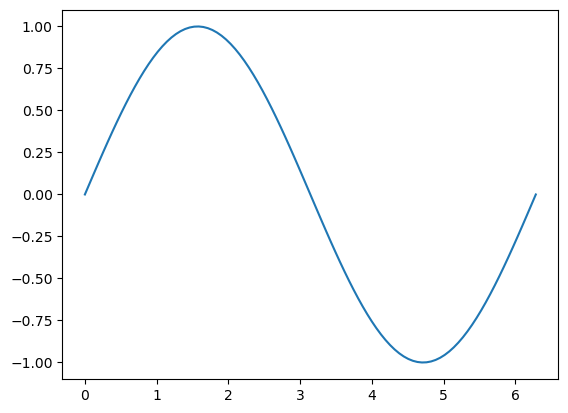

In [526]:
# Create a figure with axes
# Make drawing space
fig, ax = plt.subplots()

# Creating our 'moving' sine wave plot
# ONE line, NOT multiple lines
line, = ax.plot(x, y)

def update(frame):
    '''
    Updating my sine wave by shifting horizontally
    frame(integer) - current frame number, increasing with time
    line, (tuple) - the updated line object (being redrawn)
    '''
    line.set_ydata(np.sin(x + frame/10))

    return line,

ani = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=True)

In [527]:
# Your comment here

# There are two ways to do this (in my level):
## 1. Reduce the frame interval to half (frame/10 --> frame/5).
## This code makes the sine wave images to be updated twice as faster
## while maintaining their shape, so its speed would be doubled.

## 2. Double the frame per second (fps=20 --> fps=40).
## This changes the frames that are dislayed during one second,
## therefore its speed should appear faster

# Overall, method number 2 generates smoother animation

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [528]:
# Your code here
# Save animation as GIF
ani.save("animation_2xfast.gif", writer='pillow', fps=40)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [529]:
# Your comment here

# I Seriously could not tell the difference between the two, so I searched up on Google.
# blit=True usually generates a smoother animation because it uses previously drawn figure
# to redraw the next figure on it. Meanwhile, blit=False draws a whole new figure on the frame.
# blit=False might not be efficient on the simple animations (like sine wave) but it is more useful on
# more complex animations that redrawing on the previous figure is too complicated. 

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

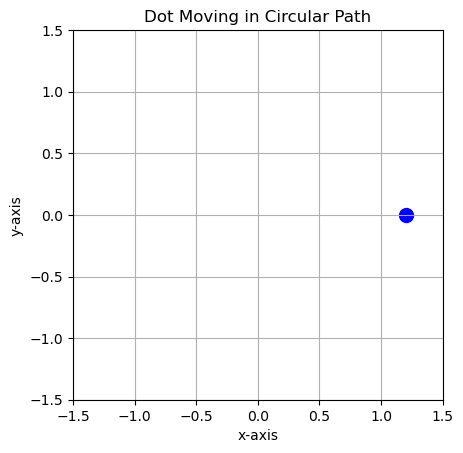

In [530]:
# I have referred to Grok for the parts initializing, adding a scatter plot, and saving the GIF.

from matplotlib.animation import FuncAnimation, PillowWriter

# Create figure and axis to plot circluar path and blue dot
fig, ax = plt.subplots()
ax.set_aspect('equal') # I added this to ensure that the path is a proper circle
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

# Define parameters: radius and angle theta
radius = 1.2
theta = np.linspace(0, 2 * np.pi, 100)

# Create initial scatter plot (a single dot)
# This ensures that the figure starts with an empty plot e.g. no dot in THE fisrt frame
scatter = ax.scatter([], [], c='blue', s=100)

# Create initialization function
def init():
    scatter.set_offsets(np.array([[radius, 0]]))  # Start at the positive x-axis
    return scatter,

# Animation function
def update(frame):
    x = radius * np.cos(theta[frame])
    y = radius * np.sin(theta[frame])
    scatter.set_offsets(np.array([[x, y]]))  # Update dot position every frame
    return scatter,

# Create animation
ani = FuncAnimation(fig, animate, init_func=init,
                     frames=100, interval=50, blit=True)

# Add grid and labels
ax.grid(True)
ax.set_title('Dot Moving in Circular Path')
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [531]:
# Your code here

# Somehow I got an error with the method learnt in the lecture, so will use a new method
ani.save('circular_motion_scatter.gif', writer = PillowWriter(fps=45))

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [532]:
# Your code here
# Values adapted from NASA data (https://nssdc.gsfc.nasa.gov/planetary/planetfact.html)
from astropy import units as u

G = 6.6743e-11 # in m^3 / kg s^2
Ms = 1.9884e30 # in kg
Me = 5.9722e24 # in kg
Mm = 0.33010e24 # in kg
Mc = 6.39e20 # in kg
AU = 149.598e9 # in m
daysec = 24 * 3600 # in s

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [533]:
# Your code here
# Initial velocities
e_ap_v = 29.29e3 # in m/s
m_ap_v = 21.97e3 # in m/s
commet_v = 7000 # in m/s

Run the cell below to define some gravitational constants because we expect no mass loss:

In [534]:
# Your code here

# I will assume gravitational constants are independent of exact distance 
# (as shown in the code given below)
def grav_const(mass):
    g = G * Ms * mass
    return g

gravconst_e = grav_const(Me)
gravconst_m = grav_const(Mm)
gravconst_c = grav_const(Mc)

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [535]:
# Your code here

# Initial positions given for the Earth:
xe, ye, ze = 1.0167 * AU, 0, 0

# Do the same for other:
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [536]:
# Your code here
# Earth:
xve, yve, zve = 0, e_ap_v, 0
# Mars:
xvm, yvm, zvm = 0, m_ap_v, 0
# Comet
xvc, yvc, zvc = 0, commet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [537]:
# Your code here
# Sun's position
xs, ys, zs = 0, 0, 0
# Sun's velocity
xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [538]:
# Your code here
# Initial time
t = 0
# Change in time
dt = 1 * daysec
# Years
years = 5
sim_years = years * 365 * daysec

Create empty lists to store all of your varibles. Run the cell below.

In [539]:
# Store the orbits:
# Earth
xelist, yelist = [], []

# Mars
xmlist, ymlist = [], []

# Comet
xclist, yclist = [], []

# Sun
xslist, yslist = [], []


## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [540]:
# Your code here
while t <= sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m + fx_c) * dt / Ms ## I added contribution from a comet as well
    yvs += -(fy_e + fy_m + fy_c) * dt / Ms ## (even though its effect would be negligible)
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

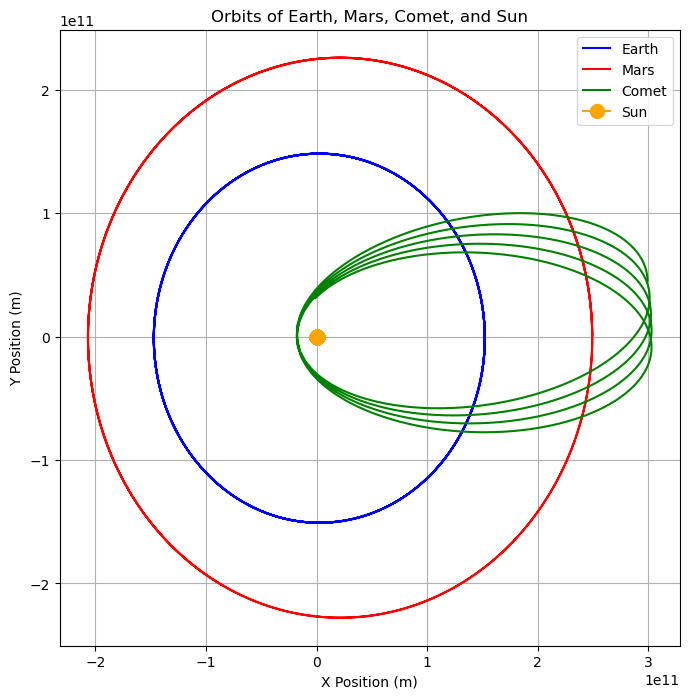

In [541]:
# Your code here 

# Create figure with figsize=(8, 8)
fig, ax = plt.subplots(figsize=(8, 8))

# Plot orbits with different colors
ax.plot(xelist, yelist, color='blue', label='Earth')   # Earth orbit in blue
ax.plot(xmlist, ymlist, color='red', label='Mars')   # Mars orbit in red
ax.plot(xclist, yclist, color='green', label='Comet')  # Comet orbit in green
ax.plot(xslist, yslist, color='orange', label='Sun', 
                marker='o', markersize=10)             # Sun as a yellow point
# Legend
ax.legend()

# Axis labels and title
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title('Orbits of Earth, Mars, Comet, and Sun')

# Add a grid
ax.grid(True)

plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

In [542]:
# Your code here

# Set x and y limits
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

# Unpack the lines for orbits (make trails)
line_e, = ax.plot([], [], '-b', lw=1, label='Earth')    # Earth orbit in blue
line_m, = ax.plot([], [], '-r', lw=1, label='Mars')     # Mars orbit in red
line_c, = ax.plot([], [], '-g', lw=1, label='Comet')    # Comet orbit in green

# Unpack the points for current positions
point_e, = ax.plot([], [], 'bo', markersize=4)                 # Earth point
point_m, = ax.plot([], [], 'ro', markersize=4)                 # Mars point
point_c, = ax.plot([], [], 'go', markersize=4)                 # Comet point
point_s, = ax.plot([], [], 'o', markersize=10, color='orange') # Sun point (larger)

# Add text labels
text_e = ax.text(AU, 0, 'Earth', color='blue')
text_m = ax.text(AU, 0, 'Mars', color='red')
text_c = ax.text(AU, 0, 'Comet', color='green')
text_s = ax.text(0, 0, 'Sun', color='orange')

# Update function for animation
def update(frame):
    # Update lines
    line_e.set_data(xelist[:frame], yelist[:frame])
    line_m.set_data(xmlist[:frame], ymlist[:frame])
    line_c.set_data(xclist[:frame], yclist[:frame])
    
    # Update points (current positions)
    point_e.set_data(xelist[frame], yelist[frame])
    point_m.set_data(xmlist[frame], ymlist[frame])
    point_c.set_data(xclist[frame], yclist[frame])
    point_s.set_data(xslist[frame], yslist[frame])
    
    # Update text positions
    text_e.set_position((xelist[frame], yelist[frame]))
    text_m.set_position((xmlist[frame], ymlist[frame]))
    text_c.set_position((xclist[frame], yclist[frame]))
    text_s.set_position((xslist[frame], yslist[frame]))
    
    return line_e, line_m, line_c, point_e, point_m, point_c, point_s, text_e, text_m, text_c, text_s

In [543]:
anim = FuncAnimation(fig, update, init_func=init, frames=len(xelist), interval=1, blit=True)

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

In [544]:
# Define gravitational constants

Mmer = 0.33010e24  # Mercury mass
Mv = 4.8673e24   # Venus mass
Mmoon = 0.07346e24  # Moon mass

gravconst_mer = grav_const(Mmer)
gravconst_v = grav_const(Mv)
gravconst_moon = grav_const(Mmoon)

# Define initial positions
xmer, ymer, zmer = 69.818e9, 0, 0
xv, yv, zv = 108.941e9, 0, 0
xmoon, ymoon, zmoon = xe + 0.4055e9, 0, 0

# Define initial velocities
xvmer, yvmer, zvmer = 0, 38.86e3, 0
xvv, yvv, zvv = 0, 34.78e3, 0
xvmoon, yvmoon, zvmoon = 0, yve + 0.970e3, 0

# Initial time
t = 0
# Change in time
dt = 1 * daysec
# Years
years = 5
sim_years = years * 365 * daysec

# Define lists for other masses
# Mercury
xmerlist, ymerlist = [], []

# Venus
xvlist, yvlist = [], []

# Moon
xmoonlist, ymoonlist = [], []

In [545]:
# Your code here

while t <= sim_years:
    ################ Mercury #############
    rx_mer, ry_mer, rz_mer = xmer - xs, ymer - ys, zmer - zs
    modr3_mer = (rx_mer**2 + ry_mer**2 + rz_mer**2)**1.5
    fx_mer = -gravconst_mer * rx_mer / modr3_mer  # Force from Sun
    fy_mer = -gravconst_mer * ry_mer / modr3_mer
    
    xvmer += fx_mer * dt / Mmer
    yvmer += fy_mer * dt / Mmer
    xmer += xvmer * dt
    ymer += yvmer * dt
    
    xmerlist.append(xmer)
    ymerlist.append(ymer)

    ################ Venus #############
    rx_v, ry_v, rz_v = xv - xs, yv - ys, zv - zs
    modr3_v = (rx_v**2 + ry_v**2 + rz_v**2)**1.5
    fx_v = -gravconst_v * rx_v / modr3_v  # Force from Sun
    fy_v = -gravconst_v * ry_v / modr3_v
    
    xvv += fx_v * dt / Mv
    yvv += fy_v * dt / Mv
    xv += xvv * dt
    yv += yvv * dt
    
    xvlist.append(xv)
    yvlist.append(yv)

    ################ Moon #############
    # Force from Sun
    rx_moon_s, ry_moon_s, rz_moon_s = xmoon - xs, ymoon - ys, zmoon - zs
    modr3_moon_s = (rx_moon_s**2 + ry_moon_s**2 + rz_moon_s**2)**1.5
    fx_moon_s = -gravconst_moon * rx_moon_s / modr3_moon_s
    fy_moon_s = -gravconst_moon * ry_moon_s / modr3_moon_s
    
    # Force from Earth
    rx_moon_e, ry_moon_e, rz_moon_e = xmoon - xe, ymoon - ye, zmoon - ze
    modr3_moon_e = (rx_moon_e**2 + ry_moon_e**2 + rz_moon_e**2)**1.5
    fx_moon_e = -G * Me * Mmoon * rx_moon_e / modr3_moon_e
    fy_moon_e = -G * Me * Mmoon * ry_moon_e / modr3_moon_e
    
    # Total force on Moon
    fx_moon = fx_moon_s + fx_moon_e
    fy_moon = fy_moon_s + fy_moon_e
    
    xvmoon += fx_moon * dt / Mmoon
    yvmoon += fy_moon * dt / Mmoon
    xmoon += xvmoon * dt
    ymoon += yvmoon * dt
    
    xmoonlist.append(xmoon)
    ymoonlist.append(ymoon)

    t += dt

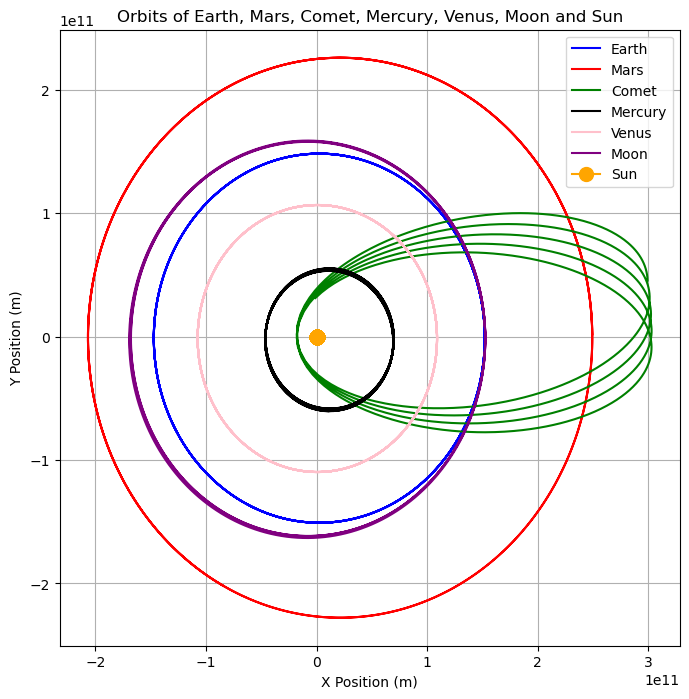

In [546]:
# Create a plot including other planets
# Create figure with figsize=(8, 8)
fig, ax = plt.subplots(figsize=(8, 8))

# Plot orbits with different colors
ax.plot(xelist, yelist, color='blue', label='Earth')   # Earth orbit in blue
ax.plot(xmlist, ymlist, color='red', label='Mars')   # Mars orbit in red
ax.plot(xclist, yclist, color='green', label='Comet')  # Comet orbit in green
ax.plot(xmerlist, ymerlist, color='black', label='Mercury')
ax.plot(xvlist, yvlist, color='pink', label='Venus')
ax.plot(xmoonlist, ymoonlist, color='purple', label='Moon')
ax.plot(xslist, yslist, color='orange', label='Sun', 
                marker='o', markersize=10)             # Sun as a yellow point
# Legend
ax.legend()

# Axis labels and title
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title('Orbits of Earth, Mars, Comet, Mercury, Venus, Moon and Sun')

# Add a grid
ax.grid(True)

plt.show()

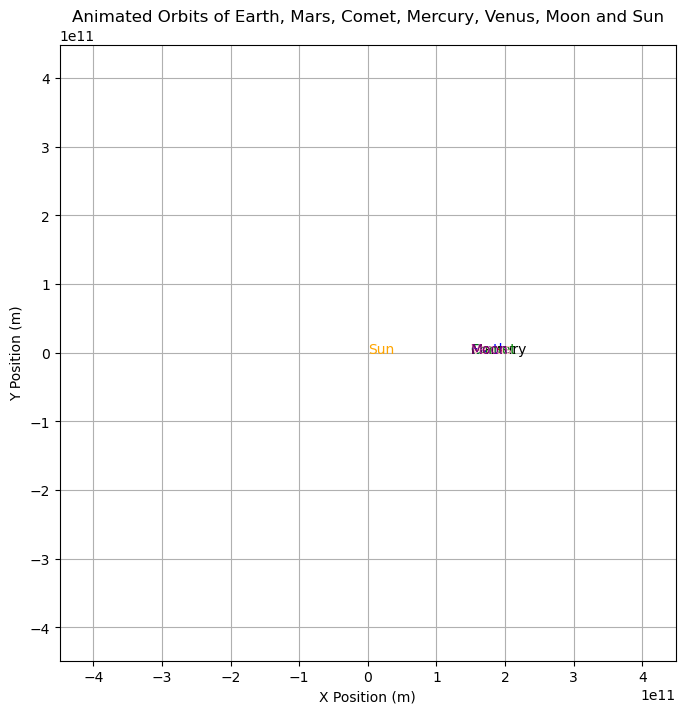

In [547]:
# Create animation
# Animation

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('Animated Orbits of Earth, Mars, Comet, Mercury, Venus, Moon and Sun')
ax.grid(True)

# Lines
line_e, = ax.plot([], [], '-b', lw=1, label='Earth')
line_m, = ax.plot([], [], '-r', lw=1, label='Mars')
line_c, = ax.plot([], [], '-g', lw=1, label='Comet')
line_mer, = ax.plot([], [], '-k', lw=1, label='Mercury')
line_v, = ax.plot([], [], color='pink', lw=1, label='Venus')
line_moon, = ax.plot([], [], color='purple', lw=1, label='Moon')

# Points
point_e, = ax.plot([], [], 'bo', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'go', markersize=4)
point_mer, = ax.plot([], [], 'ko', markersize=4)
point_v, = ax.plot([], [], color='pink', marker='o', markersize=4)
point_moon, = ax.plot([], [], color='purple', marker='o', markersize=4)
point_s, = ax.plot([], [], color='orange', marker='o', markersize=10)

# Text
text_e = ax.text(AU, 0, 'Earth', color='blue')
text_m = ax.text(AU, 0, 'Mars', color='red')
text_c = ax.text(AU, 0, 'Comet', color='green')
text_mer = ax.text(AU, 0, 'Mercury', color='black')
text_v = ax.text(AU, 0, 'Venus', color='pink')
text_moon = ax.text(AU, 0, 'Moon', color='purple')
text_s = ax.text(0, 0, 'Sun', color='orange')

def update(frame):
    line_e.set_data(xelist[:frame], yelist[:frame])
    line_m.set_data(xmlist[:frame], ymlist[:frame])
    line_c.set_data(xclist[:frame], yclist[:frame])
    line_mer.set_data(xmerlist[:frame], ymerlist[:frame])
    line_v.set_data(xvlist[:frame], yvlist[:frame])
    line_moon.set_data(xmoonlist[:frame], ymoonlist[:frame])
    
    point_e.set_data(xelist[frame], yelist[frame])
    point_m.set_data(xmlist[frame], ymlist[frame])
    point_c.set_data(xclist[frame], yclist[frame])
    point_mer.set_data(xmerlist[frame], ymerlist[frame])
    point_v.set_data(xvlist[frame], yvlist[frame])
    point_moon.set_data(xmoonlist[frame], ymoonlist[frame])
    point_s.set_data(xslist[frame], yslist[frame])
    
    text_e.set_position((xelist[frame], yelist[frame]))
    text_m.set_position((xmlist[frame], ymlist[frame]))
    text_c.set_position((xclist[frame], yclist[frame]))
    text_mer.set_position((xmerlist[frame], ymerlist[frame]))
    text_v.set_position((xvlist[frame], yvlist[frame]))
    text_moon.set_position((xmoonlist[frame], ymoonlist[frame]))
    text_s.set_position((xslist[frame], yslist[frame]))
    
    return [line_e, line_m, line_c, line_mer, line_v, line_moon, point_e, point_m, point_c, 
            point_mer, point_v, point_moon, point_s, text_e, text_m, text_c, text_mer, text_v, text_moon, text_s]

anim = FuncAnimation(fig, update, init_func=init, frames=len(xelist), blit=True)

plt.show()

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [558]:
# Your code here
# anim.save("planetary_orbits.gif", writer='pillow', fps=40)

Upload this notebook and your animations to Gradescope!

In [557]:
### I managed to get the plots but failed to make animations, keep getting 
### IndexError: list index out of range
### RuntimeError: x must be a sequence